In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,roc_auc_score

In [3]:
df = pd.read_csv(r"D:\Anaconda\Projects\Project delay prediction\SAMPLE DATA(Book2).csv")
df   #load csv file

,TaskID,ProjectID,ProjectDiscipline,Status,Description,Location,Created,Target,Actual,Delay,Priority,Overdue,RootCause,Risk,Hours,Comments
0,T-1015,PRJ001,PRJ-STR,Closed,Column Installation,Grid A5,2/1/2024,2/5/2024,2/7/2024,2.0,High,True,Crane Breakdown,High,56,Repaired after 1 day
1,T-1016,PRJ001,PRJ-INT,Open,Paint Finishes,Lobby,5/10/2024,5/20/2024,NaN,NaN,Medium,False,NaN,Medium,38,Awaiting color approval
2,T-1017,PRJ001,PRJ-MEP,Closed,HVAC Ductwork,Mechanical,3/15/2024,3/22/2024,3/18/2024,-4.0,Medium,False,NaN,Low,72,Ahead of schedule
3,T-1018,PRJ001,PRJ-ARC,Closed,Curtain Wall Install,South Facade,4/1/2024,4/15/2024,4/20/2024,5.0,High,True,Design Revision,High,120,Required engineering sign-off
4,T-1019,PRJ001,PRJ-SITE,Closed,Underground Utilities,West Yard,1/10/2024,1/25/2024,2/5/2024,11.0,High,True,Weather Delay,Medium,90,Heavy rains for 1 week
5,T-1020,PRJ001,PRJ-STR,Closed,Deck Pour,Level 3,3/5/2024,3/8/2024,3/8/2024,0.0,High,False,NaN,High,64,Perfect weather conditions
6,T-1021,PRJ001,PRJ-INT,Closed,Floor Tile,Restrooms,4/10/2024,4/12/2024,4/15/2024,3.0,Medium,True,Material Defect,Medium,45,Initial batch rejected
7,T-1022,PRJ001,PRJ-MEP,Open,Fire Alarm Wiring,Level 2,5/1/2024,5/10/2024,NaN,NaN,Medium,False,NaN,Medium,28,Coordinating with electrician
8,T-1023,PRJ001,PRJ-ARC,Closed,Roof Membrane,Penthouse,2/20/2024,2/25/2024,2/24/2024,-1.0,High,False,NaN,High,80,Completed before deadline
9,T-1024,PRJ001,PRJ-SITE,Closed,Parking Lot Paving,North Lot,4/15/2024,4/20/2024,4/22/2024,2.0,Medium,True,Asphalt Shortage,Medium,60,Truck delivery delay


#### Data cleaning and Preprocessing

In [4]:
df['Created'] = pd.to_datetime(df['Created'], errors = 'coerce')
df['Target'] = pd.to_datetime(df['Target'], errors = 'coerce')
df['Actual'] = pd.to_datetime(df['Actual'], errors = 'coerce') # convert date to datetime

In [5]:
df_clean = df.dropna(subset = ['Actual', 'Delay']) # drop rows with missing Actual or Delay

In [6]:
df_clean = df_clean.copy()
df_clean['Risk_Level'] = df_clean['Risk'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_clean['Priority_Level'] = df_clean['Priority'].map({'Low': 0, 'Medium': 1, 'High': 2}) #encode categorical variabes

In [7]:
df.head()

,TaskID,ProjectID,ProjectDiscipline,Status,Description,Location,Created,Target,Actual,Delay,Priority,Overdue,RootCause,Risk,Hours,Comments
0,T-1015,PRJ001,PRJ-STR,Closed,Column Installation,Grid A5,2024-02-01,2024-02-05,2024-02-07,2.0,High,True,Crane Breakdown,High,56,Repaired after 1 day
1,T-1016,PRJ001,PRJ-INT,Open,Paint Finishes,Lobby,2024-05-10,2024-05-20,NaT,NaN,Medium,False,NaN,Medium,38,Awaiting color approval
2,T-1017,PRJ001,PRJ-MEP,Closed,HVAC Ductwork,Mechanical,2024-03-15,2024-03-22,2024-03-18,-4.0,Medium,False,NaN,Low,72,Ahead of schedule
3,T-1018,PRJ001,PRJ-ARC,Closed,Curtain Wall Install,South Facade,2024-04-01,2024-04-15,2024-04-20,5.0,High,True,Design Revision,High,120,Required engineering sign-off
4,T-1019,PRJ001,PRJ-SITE,Closed,Underground Utilities,West Yard,2024-01-10,2024-01-25,2024-02-05,11.0,High,True,Weather Delay,Medium,90,Heavy rains for 1 week


### EDA

### Histogram of Delay

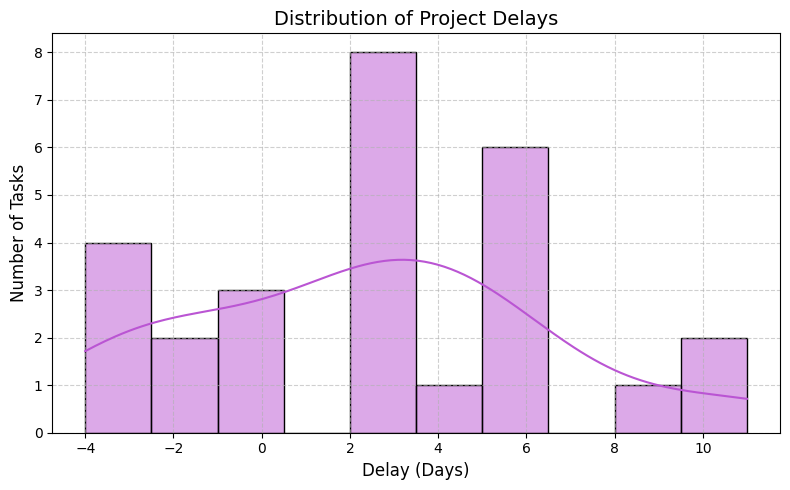

In [8]:
#Plot 1: Distribution of Delay
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='Delay', bins=10, kde=True, color='mediumorchid', edgecolor='black')
plt.title("Distribution of Project Delays", fontsize=14)    # Labels and title
plt.xlabel("Delay (Days)", fontsize=12)
plt.ylabel("Number of Tasks", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)        # Grid and layout
plt.tight_layout()
plt.show()

### Average Delay by Risk Level

C:\Users\user\AppData\Local\Temp\ipykernel_21928\3201649955.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Risk', y='Delay', data=df_clean, palette='magma')


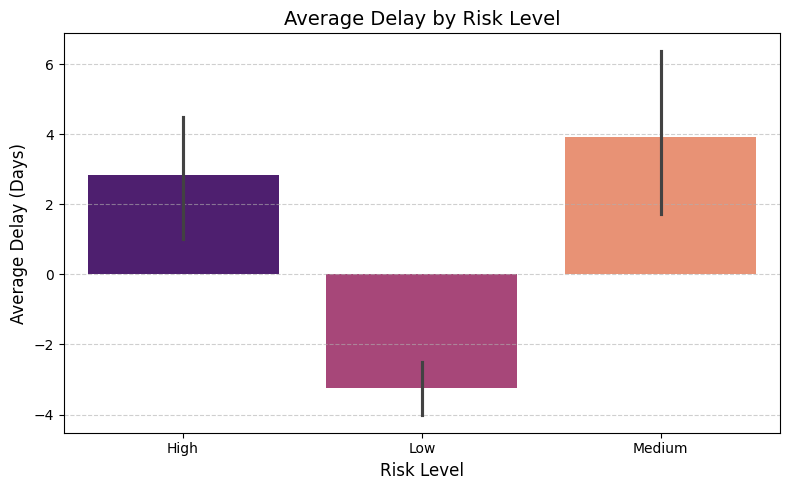

In [9]:
#Plot 2: Average Delay by Risk Level
plt.figure(figsize=(8, 5))
sns.barplot(x='Risk', y='Delay', data=df_clean, palette='magma')
plt.title("Average Delay by Risk Level", fontsize=14)
plt.xlabel("Risk Level", fontsize=12)
plt.ylabel("Average Delay (Days)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Resource Hours vs. Delay

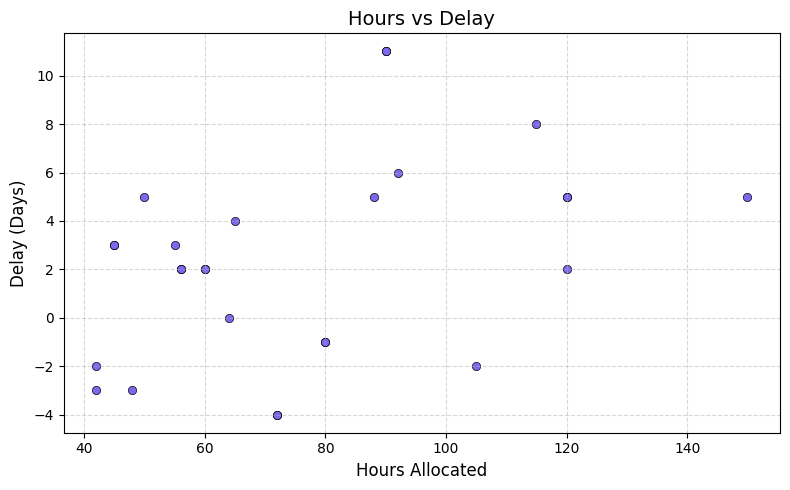

In [10]:
#Plot 3: Hours vs Delay
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Hours', y='Delay', data=df_clean, color='mediumslateblue', edgecolor='black')
plt.title("Hours vs Delay", fontsize=14)   # Labels and title
plt.xlabel("Hours Allocated", fontsize=12)
plt.ylabel("Delay (Days)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()  # Grid and layout

### Feature Selection and Train/Test Split

In [11]:
x = df_clean[['Risk_Level', 'Priority_Level', 'Hours']]
y = df_clean['Overdue'].astype(int)
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [12]:
model = LogisticRegression()
model.fit(xtrain,ytrain)
y_pred = model.predict(xtest)  #train logistic regression

In [27]:
accuracy = accuracy_score(ytest, y_pred)
roc_auc = roc_auc_score(ytest, model.predict_proba(xtest)[:,1])
print(f"Model Accuracy: {accuracy:.2f}")
print(f"ROC-AUC Score: {roc_auc:.2f}")  #evaluate model

Model Accuracy: 0.33
ROC-AUC Score: 0.50


### Mitigation Strategy

In [14]:
# increasing hours when Risk_Level = 2
df_sim = df_clean.copy()
df_sim['Adjusted_Hours'] = df_sim.apply(
    lambda row: row['Hours'] + 20 if row['Risk_Level'] == 2 else row['Hours'], axis=1)

In [15]:
# Prepare original and simulated feature sets
X_original = df_clean[['Risk_Level', 'Priority_Level', 'Hours']]
X_simulated = df_sim[['Risk_Level', 'Priority_Level', 'Adjusted_Hours']].rename(columns={'Adjusted_Hours': 'Hours'})

In [16]:
# Predict delay probabilities
df_sim['Original_Prob'] = model.predict_proba(X_original)[:, 1]
df_sim['Adjusted_Prob'] = model.predict_proba(X_simulated)[:, 1]

In [17]:
df_sim[['TaskID', 'Risk_Level', 'Hours', 'Adjusted_Hours', 'Original_Prob', 'Adjusted_Prob']].head()

,TaskID,Risk_Level,Hours,Adjusted_Hours,Original_Prob,Adjusted_Prob
0,T-1015,2,56,76,0.618725,0.748378
2,T-1017,0,72,72,0.731993,0.731993
3,T-1018,2,120,140,0.918551,0.953852
4,T-1019,1,90,90,0.794393,0.794393
5,T-1020,2,64,84,0.674032,0.791223


In [18]:
#Bar Plot of What-If for Risk Level 2
df_risk2 = df_sim[df_sim['Risk_Level'] == 2].head(10)  # take top 10 risk =2

In [19]:
import numpy as np
x = np.arange(len(df_risk2)) # position of bar

In [20]:
bar_width = 0.35 #width of the bar

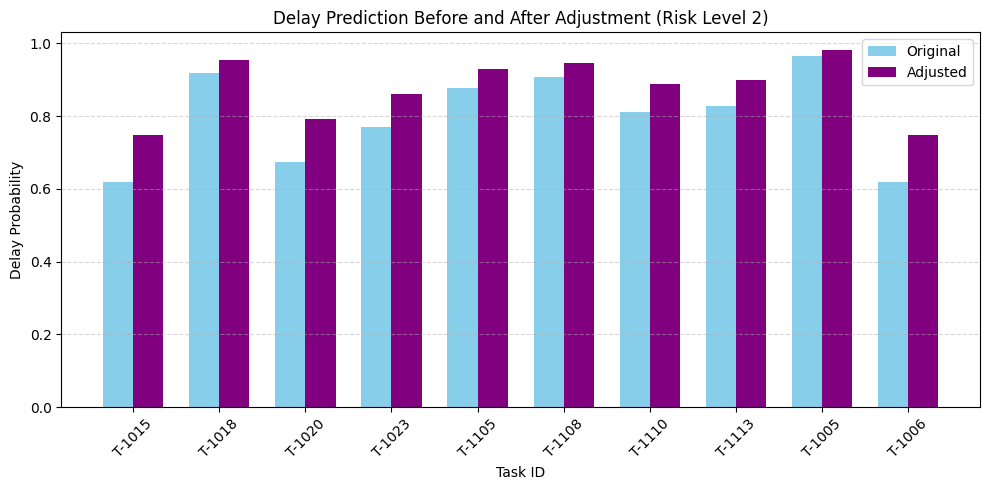

In [21]:
#Plotting
plt.figure(figsize=(10, 5))
plt.bar(x - bar_width/2, df_risk2['Original_Prob'], width=bar_width, label='Original', color='skyblue')
plt.bar(x + bar_width/2, df_risk2['Adjusted_Prob'], width=bar_width, label='Adjusted', color='purple') 
plt.xlabel('Task ID')
plt.ylabel('Delay Probability')
plt.title('Delay Prediction Before and After Adjustment (Risk Level 2)')
plt.xticks(x, df_risk2['TaskID'], rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()   #Label and Title

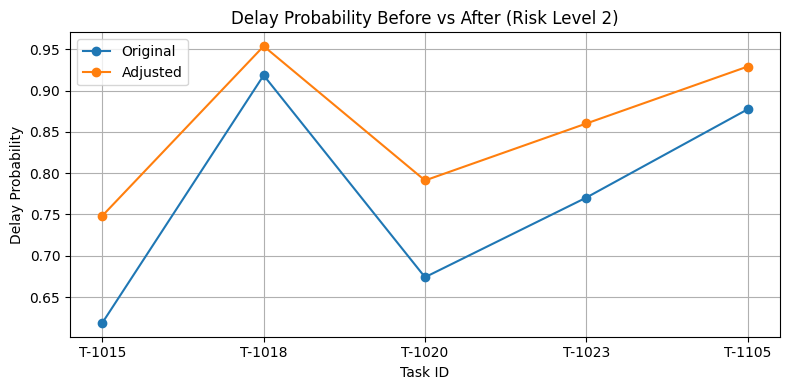

In [22]:
#Line Plot: Delay Probabilities
df_risk2 = df_sim[df_sim['Risk_Level'] == 2].head(5)
plt.figure(figsize=(8, 4))
# Plot original and adjusted probabilities
plt.plot(df_risk2['TaskID'], df_risk2['Original_Prob'], label='Original', marker='o')
plt.plot(df_risk2['TaskID'], df_risk2['Adjusted_Prob'], label='Adjusted', marker='o')
plt.title("Delay Probability Before vs After (Risk Level 2)")
plt.xlabel("Task ID")
plt.ylabel("Delay Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

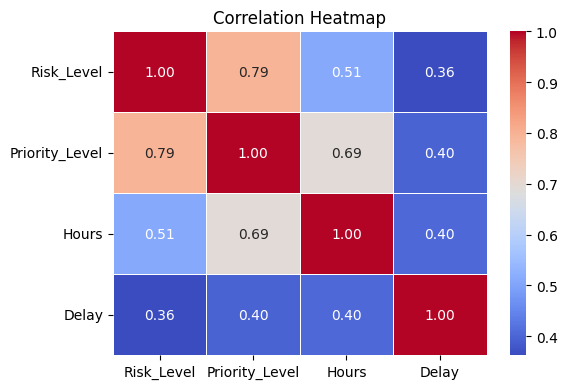

In [23]:
#Correlation Heatmap
corr = df_clean[['Risk_Level', 'Priority_Level', 'Hours', 'Delay']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [1]:
#from sklearn.ensemble import RandomForestClassifier
#from xgboost import XGBClassifier

In [2]:
# #random Forest
# rf = RandomForestClassifier()
# rf.fit(xtrain, ytrain)
# print("Random Forest Accuracy:", accuracy_score(ytest, rf.predict(xtest)))

In [3]:
# #XGBoost
# xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
# xgb.fit(xtrain, ytrain)
# print("XGBoost Accuracy:", accuracy_score(ytest, xgb.predict(xtest)))